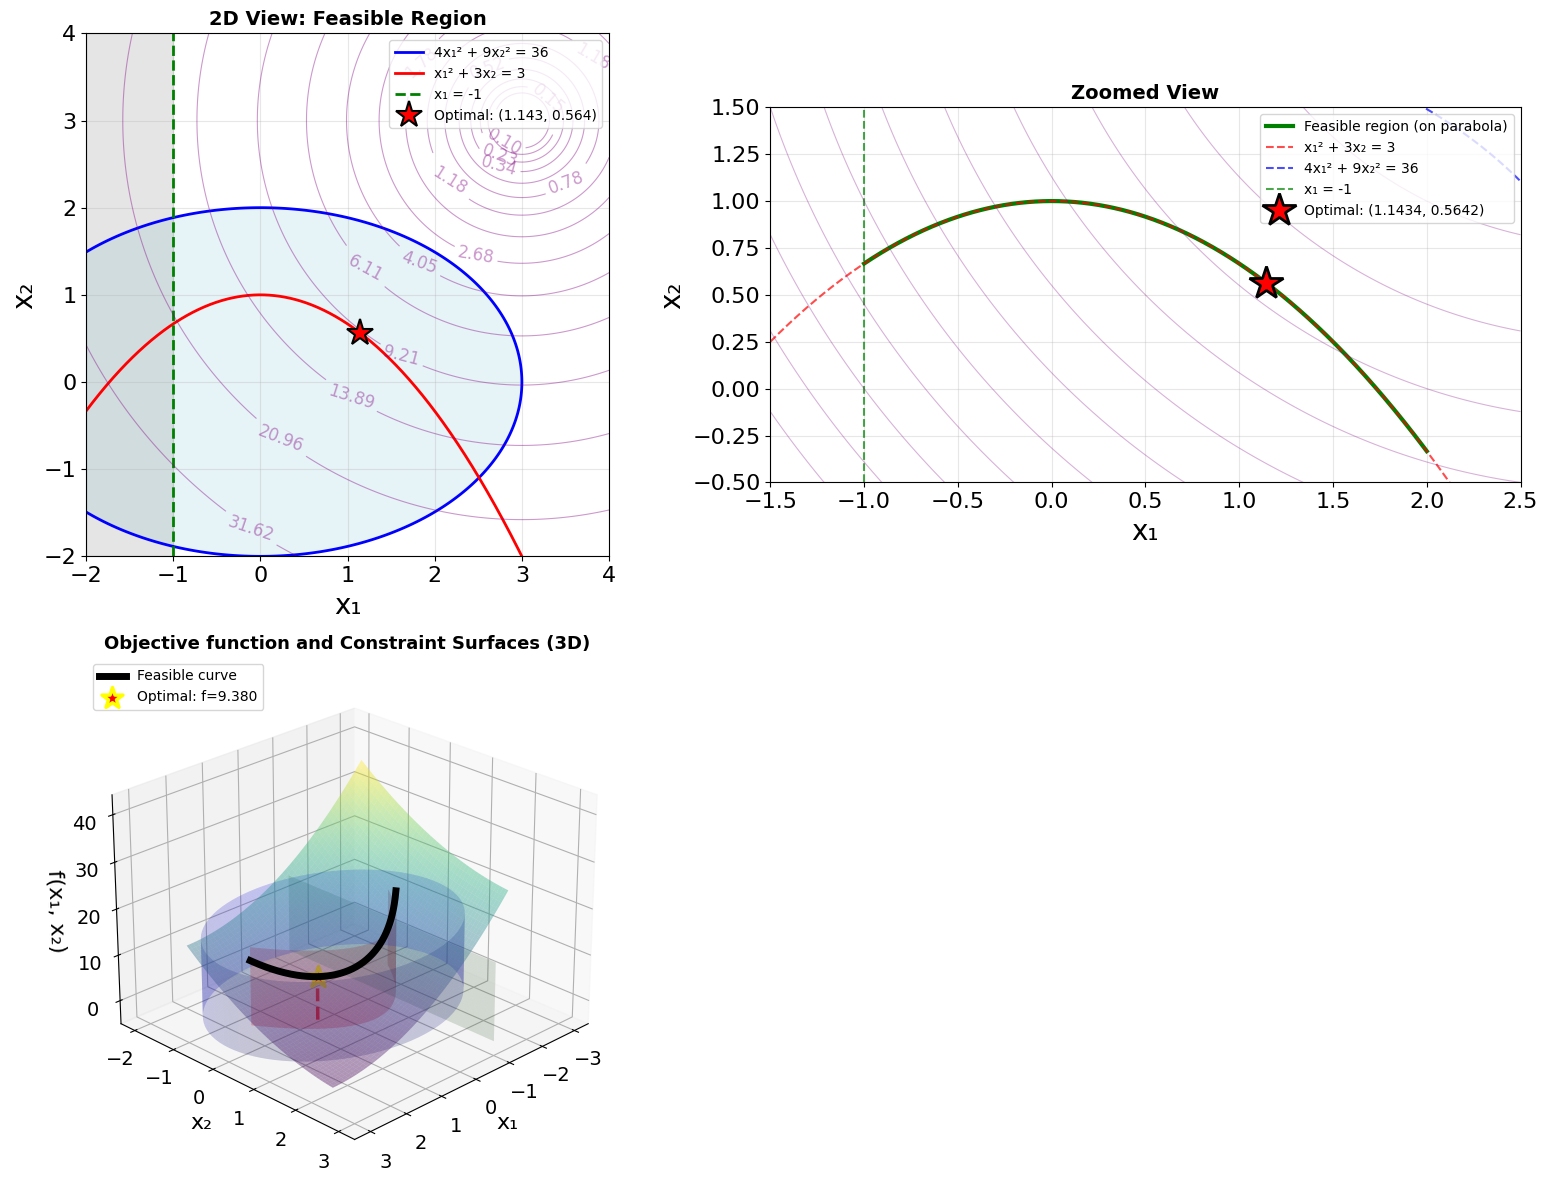

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

def objective(x):
    return (x[0] - 3)**2 + (x[1] - 3)**2

def constraint1(x):
    return 36 - (4*x[0]**2 + 9*x[1]**2)  # >= 0 form

def constraint2(x):
    return 3 - (x[0]**2 + 3*x[1])  # = 0 form

def constraint3(x):
    return x[0] + 1  # x1 >= -1, so x1 + 1 >= 0

fig = plt.figure(figsize=(16, 12))

# 2D Feasible region with constraints
ax1 = plt.subplot(2, 2, 1)

x1 = np.linspace(-2, 4, 500)
x2 = np.linspace(-2, 4, 500)
X1, X2 = np.meshgrid(x1, x2)

# Constraint 1
C1 = 4*X1**2 + 9*X2**2

# Constraint 2
x1_parabola = np.linspace(-2, 4, 1000)
x2_parabola = (3 - x1_parabola**2) / 3

# Plot ellipse constraint
ellipse_contour = ax1.contour(X1, X2, C1, levels=[36], colors='blue', linewidths=2)
ax1.contourf(X1, X2, C1, levels=[0, 36], colors=['lightblue'], alpha=0.3)

# Plot parabola constraint
parabola_line, = ax1.plot(x1_parabola, x2_parabola, 'r-', linewidth=2, label='x₁² + 3x₂ = 3')

# Plot x1 >= -1 constraint
bound_line = ax1.axvline(x=-1, color='green', linewidth=2, linestyle='--', label='x₁ = -1')
ax1.axvspan(-2, -1, alpha=0.2, color='gray')

# Objective function contours
Z = (X1 - 3)**2 + (X2 - 3)**2
contour_levels = np.logspace(-1, 1.5, 15)
cs = ax1.contour(X1, X2, Z, levels=contour_levels, colors='purple', alpha=0.4, linewidths=0.8)
ax1.clabel(cs, inline=True, fontsize=12)

# Solve the optimization problem
cons = [
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'eq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3}
]

# Try multiple initial points to find global optimum
best_result = None
best_obj = float('inf')

initial_points = [
    [0, 1],
    [1, 0.67],
    [-0.5, 1],
    [1.5, 0.25],
    [0.5, 0.9]
]
for x0 in initial_points:
    result = minimize(objective, x0, method='SLSQP', constraints=cons)
    if result.success and result.fun < best_obj:
        best_obj = result.fun
        best_result = result

if best_result and best_result.success:
    x_opt = best_result.x
    f_opt = best_result.fun
    
    # Plot optimal solution
    opt_point, = ax1.plot(x_opt[0], x_opt[1], 'r*', markersize=20, 
                          markeredgecolor='black', markeredgewidth=1.5,
                          label=f'Optimal: ({x_opt[0]:.3f}, {x_opt[1]:.3f})')

from matplotlib.lines import Line2D
ellipse_proxy = Line2D([0], [0], color='blue', linewidth=2, label='4x₁² + 9x₂² = 36')
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.set_xlabel('x₁', fontsize=20)
ax1.set_ylabel('x₂', fontsize=20)
ax1.set_title('2D View: Feasible Region', fontsize=14, fontweight='bold')
ax1.legend(handles=[ellipse_proxy, parabola_line, bound_line, opt_point], loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2, 4)
ax1.set_ylim(-2, 4)
ax1.set_aspect('equal')

# Plot 2
ax2 = plt.subplot(2, 2, 2)

# Find feasible points on the parabola
x1_feasible = []
x2_feasible = []

for x1_val in np.linspace(-1, 2, 1000):
    x2_val = (3 - x1_val**2) / 3
    if 4*x1_val**2 + 9*x2_val**2 <= 36 and x1_val >= -1:
        x1_feasible.append(x1_val)
        x2_feasible.append(x2_val)

ax2.plot(x1_feasible, x2_feasible, 'g-', linewidth=3, label='Feasible region (on parabola)')

# Plot constraints
x1_plot = np.linspace(-1.5, 2.5, 500)
x2_plot = (3 - x1_plot**2) / 3
ax2.plot(x1_plot, x2_plot, 'r--', linewidth=1.5, alpha=0.7, label='x₁² + 3x₂ = 3')

# Ellipse
theta = np.linspace(0, 2*np.pi, 1000)
ellipse_x1 = 3 * np.cos(theta)
ellipse_x2 = 2 * np.sin(theta)
ax2.plot(ellipse_x1, ellipse_x2, 'b--', linewidth=1.5, alpha=0.7, label='4x₁² + 9x₂² = 36')

# Vertical line at x1 = -1
ax2.axvline(x=-1, color='green', linewidth=1.5, linestyle='--', alpha=0.7, label='x₁ = -1')

# Objective function contours (zoomed)
x1_zoom = np.linspace(-1.5, 2.5, 400)
x2_zoom = np.linspace(-0.5, 1.5, 400)
X1_zoom, X2_zoom = np.meshgrid(x1_zoom, x2_zoom)
Z_zoom = (X1_zoom - 3)**2 + (X2_zoom - 3)**2
cs2 = ax2.contour(X1_zoom, X2_zoom, Z_zoom, levels=12, colors='purple', alpha=0.3, linewidths=0.8)

if best_result and best_result.success:
    ax2.plot(x_opt[0], x_opt[1], 'r*', markersize=25, label=f'Optimal: ({x_opt[0]:.4f}, {x_opt[1]:.4f})', 
             markeredgecolor='black', markeredgewidth=2)

ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.set_xlabel('x₁', fontsize=20)
ax2.set_ylabel('x₂', fontsize=20)
ax2.set_title('Zoomed View', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1.5, 2.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_aspect('equal')

# Plot 3: 3D Combined - Objective function surface with constraint surfaces
ax3 = plt.subplot(2, 2, 3, projection='3d')

# Create mesh for objective function
x1_3d = np.linspace(-2, 3, 150)
x2_3d = np.linspace(-1, 2.5, 150)
X1_3d, X2_3d = np.meshgrid(x1_3d, x2_3d)
Z_3d = (X1_3d - 3)**2 + (X2_3d - 3)**2

# Plot objective function surface 
surf = ax3.plot_surface(X1_3d, X2_3d, Z_3d, cmap='viridis', alpha=0.4, edgecolor='none')

# (x1^2 + 3*x2 = 3)
x1_para_surf = np.linspace(-2, 2, 100)
z_para_surf = np.linspace(-2, 15, 100)
X1_para, Z_para = np.meshgrid(x1_para_surf, z_para_surf)
X2_para = (3 - X1_para**2) / 3
ax3.plot_surface(X1_para, X2_para, Z_para, alpha=0.25, color='red', edgecolor='none')

# 4x1^2 + 9x2^2 = 36
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(-2, 15, 100)
U, V = np.meshgrid(u, v)
X1_ellipse = 3 * np.cos(U)
X2_ellipse = 2 * np.sin(U)
Z_ellipse = V
ax3.plot_surface(X1_ellipse, X2_ellipse, Z_ellipse, alpha=0.2, color='blue', edgecolor='none')

# Plane x1 = -1
x2_plane = np.linspace(-2, 3, 50)
z_plane = np.linspace(-2, 15, 50)
X2_plane, Z_plane = np.meshgrid(x2_plane, z_plane)
X1_plane = -1 * np.ones_like(X2_plane)
ax3.plot_surface(X1_plane, X2_plane, Z_plane, alpha=0.15, color='green', edgecolor='none')

# Plot feasible curve on objective function surface
x1_para = np.linspace(-1, 2, 200)
x2_para = (3 - x1_para**2) / 3
z_para = (x1_para - 3)**2 + (x2_para - 3)**2
mask = (4*x1_para**2 + 9*x2_para**2 <= 36)
x1_feas_3d = x1_para[mask]
x2_feas_3d = x2_para[mask]
z_feas_3d = z_para[mask]
ax3.plot(x1_feas_3d, x2_feas_3d, z_feas_3d, 'black', linewidth=5, label='Feasible curve', zorder=10)

# Plot optimal point
if best_result and best_result.success:
    ax3.scatter([x_opt[0]], [x_opt[1]], [f_opt], color='red', s=250, marker='*', 
                edgecolors='yellow', linewidths=2.5, label=f'Optimal: f={f_opt:.3f}', zorder=11)
    ax3.plot([x_opt[0], x_opt[0]], [x_opt[1], x_opt[1]], [0, f_opt], 
             'r--', linewidth=2.5, alpha=0.8)

ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_xlabel('x₁', fontsize=16)
ax3.set_ylabel('x₂', fontsize=16)
ax3.set_zlabel('f(x₁, x₂)', fontsize=16)
ax3.set_title('Objective function and Constraint Surfaces (3D)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='upper left')
ax3.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

